# T10 — A rift, and the point at which it stops being one

**Cluster D — Part 3, lithospheric deformation.** Requires the container.

T09 left the model one ingredient short of a rift. The Spiegelman benchmark is
*instantaneous*: one nonlinear solve, nothing moves, no strain accumulates, and
so nothing rewards a shear band for having formed. Its band width turned out to
be set by the seed, because there was no feedback to drive localisation any
further.

This notebook closes the loop:

$$\text{yielding} \;\rightarrow\; \text{plastic strain} \;\rightarrow\;
  \text{weaker rock} \;\rightarrow\; \text{more yielding}$$

and the model does then localise — a symmetric conjugate pair beneath the axis
with a multi-strand fault array through the brittle crust.

It also runs out of validity after about forty steps, in two independent ways,
and finding out *why* is at least as much of the notebook as the rift is. A
model that tells you when to stop believing it is worth more than one that
doesn't.

## Learning objectives

1. Assemble a time-dependent lithospheric model: advected materials, accumulated plastic strain, strain weakening.
2. State the invariant a conservative level set obeys, and enforce it rather than print it.
3. Read a localisation diagnostic without being fooled by it.
4. Work out, from the boundary conditions and the mesh, how long your own model is entitled to run.

## Prerequisites and runtime

* T09. **Requires the container.**
* **Measured runtime: 13 minutes.** Two model runs, one of which is
  supposed to fail.

In [1]:
# === USER CONFIGURATION ===
NX, NY = 64, 32           # 96x48 results are quoted where they differ
STEPS = 36                # why 36 and not 400 is section 6
HEATFLOW = 0.055          # W/m2 at the surface; section 7 explains the value
SEED_KM = 10.0            # half-width of the weak seed

In [2]:
import json
import os
import subprocess
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from geodynkit import plotting, lithosphere as LI

DRIVER = os.path.join("..", "tools", "gadopt_rift_case.py")


def run(tag, **kw):
    """Run the rift driver. Returns (RESULT dict, per-step history)."""
    cmd = [sys.executable, DRIVER, "--nx", str(NX), "--ny", str(NY),
           "--out", f"{tag}.npz", "--history", f"{tag}_history.json"]
    for k, v in kw.items():
        cmd += [f"--{k.replace('_', '-')}", str(v)]
    p = subprocess.run(cmd, capture_output=True, text=True)
    res = None
    for line in p.stdout.splitlines():
        if line.startswith("RESULT "):
            res = json.loads(line[len("RESULT "):])
    if res is None:
        raise RuntimeError(f"no result:\n{p.stderr[-1500:]}")
    hist = json.load(open(f"{tag}_history.json"))
    return res, hist

## 1. The three pieces

**Materials that keep their identity.** Three layers — 20 km upper crust,
20 km lower crust, 60 km mantle lithosphere — carried by two **conservative
level sets** through `LevelSetSolver`. A conservative level set $\psi$ is a
smoothed indicator function: $\psi$ is the volume fraction of material above the
interface, so $\psi \in [0, 1]$ by construction. Remember that; section 3 is
about what happens when it stops being true.

**Strain that accumulates and travels.** `GenericTransportSolver` advects a
scalar plastic-strain field with a source term equal to the plastic strain rate
where the plastic branch governs:

$$\frac{\partial \varepsilon_p}{\partial t} + \mathbf{u}\cdot\nabla\varepsilon_p
  = \dot\varepsilon_{II}\,\big[\mu_{\text{plast}} < \mu_{\text{creep}}\big]$$

Strain has to be *advected*, not just accumulated in place, or a fault would
stay behind while the rock that broke moves away.

**A weakening law.** Cohesion and friction fall linearly from full strength at
$\varepsilon_p = 0.5$ to a quarter of it at $\varepsilon_p = 1.5$, after
Naliboff & Buiter (2015). That is the arrow that closes the loop.

The layer properties, flow laws and weakening parameters live in
`geodynkit.lithosphere` with their provenance. Start, as always with a
lithospheric model, by looking at the strength envelope rather than the solver.

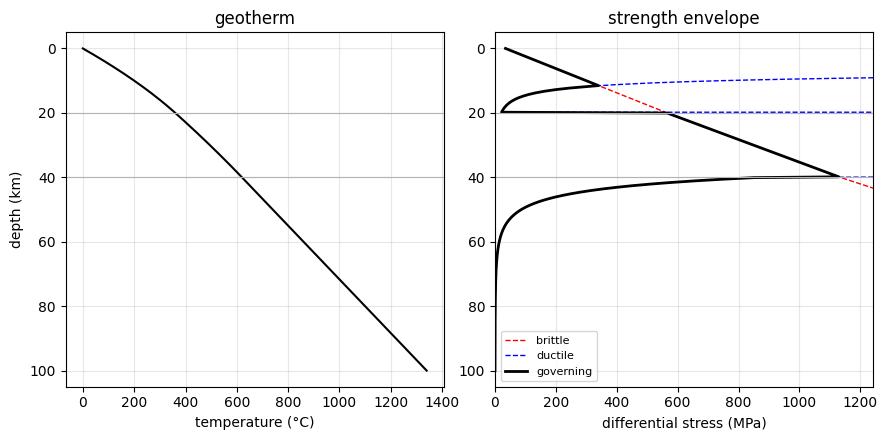

surface heat flow 0.055 W/m2 -> 1340 °C at 100 km (the base of the lithosphere should be ~1300 °C)


In [3]:
env = LI.strength_envelope(surface_heat_flow=HEATFLOW)
fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].plot(env["temperature"] - 273.15, env["depth_km"], "k-")
ax[0].set(xlabel="temperature (°C)", ylabel="depth (km)", title="geotherm")
ax[1].plot(env["brittle_MPa"], env["depth_km"], "r--", lw=1, label="brittle")
ax[1].plot(env["ductile_MPa"], env["depth_km"], "b--", lw=1, label="ductile")
ax[1].plot(env["strength_MPa"], env["depth_km"], "k-", lw=2, label="governing")
ax[1].set(xlabel="differential stress (MPa)", title="strength envelope",
          xlim=(0, min(1500, 1.1 * np.nanmax(env["strength_MPa"]))))
ax[1].legend(fontsize=8)
for a in ax:
    a.invert_yaxis()
    a.grid(alpha=0.3)
    for b in (20, 40):
        a.axhline(b, color="0.7", lw=0.8)
fig.tight_layout()
plt.show()

print(f"surface heat flow {HEATFLOW} W/m2 -> "
      f"{float(LI.geotherm(100.0, surface_heat_flow=HEATFLOW)) - 273.15:.0f} °C "
      "at 100 km (the base of the lithosphere should be ~1300 °C)")

The dashed lines cross where the deformation mechanism changes. Each crossing is
a **brittle–ductile transition**, and where they sit relative to the layer
boundaries is what decides whether the crust and mantle deform together or
independently — the classical control on narrow versus wide rifting.

## 2. Why the geotherm is not a free parameter

It is tempting to treat the surface heat flow as a knob and tune it until the
model does something interesting. Resist that, and the check is one line: a
100 km lithosphere should have its base near the mantle adiabat, about 1300 °C.

| $q_0$ (W/m²) | T(20 km) | T(40 km) | T(100 km) | |
|---|---|---|---|---|
| 0.040 | 240 °C | 380 °C | 740 °C | far too cold |
| 0.048 | 304 °C | 508 °C | 1060 °C | still cold |
| **0.055** | 360 °C | 620 °C | **1340 °C** | about right |

When this suite was built, a parameter sweep chose $q_0 = 0.040$ because it
scored highest on total accumulated strain. That is exactly backwards: at
0.040 the mantle lithosphere is so cold it sits pinned at the $10^{26}$ Pa s
viscosity ceiling and cannot deform at all, so the entire extension is forced
into the crust, which then fails everywhere — 74% of the domain fully weakened.
A rigid mantle *maximises* crustal strain. The metric rewarded the failure it
was meant to detect, which is a theme of this notebook and of section 7.

## 3. An invariant, enforced

$\psi \in [0, 1]$ is not a guideline. `material_field` blends layer properties by
interpolating in $\psi$, so $\psi = 3$ produces a density no rock has. The first
production run of this model finished 400 steps in 2 h 22 min with level sets
spanning $[-1.72, 3.02]$, and its density field had mantle at 5 km depth and
crustal density at 90 km. Every figure made from it was meaningless.

The range had been measured all along. It was printed once, at the end.

**A diagnostic that only prints is not a check.** The driver now tests the bound
every step and raises. Here is that happening: the same model, deliberately
starved of reinitialisation and given a tight tolerance.

In [4]:
bad, bad_hist = run("rift_bad", steps=20, heatflow=HEATFLOW, seed_km=SEED_KM,
                    reini_steps=2, ls_tol=0.005)
print(f"\nfailure: {bad['failure']}")
print(f"stopped after {bad['steps_completed']} of {bad['steps_requested']} steps")


failure: AdvectionBroke: level set range [-0.0012, 1.0053] at step 14: the conservative level set must stay in [0, 1]. Everything downstream of the material field is now meaningless.
stopped after 15 of 20 steps


Reinitialisation is what restores the $\tanh$ interface profile that advection
smears. Two sweeps per timestep is not enough; twelve is, and the difference is
almost free because the Stokes solve dominates the cost:

| reinitialisation sweeps | $\psi$ excursion beyond [0,1] at step 20 | wall clock |
|---|---|---|
| 2 | 0.0277 | 481 s |
| 6 | 0.0148 | 493 s |
| 12 | **0.0048** | 506 s |

## 4. The model

Now the real run: 36 steps, twelve reinitialisation sweeps, the invariants armed.

In [5]:
res, hist = run("rift", steps=STEPS, heatflow=HEATFLOW, seed_km=SEED_KM,
                reini_steps=12, picard_iters=40)
print(f"\nfailure      {res['failure']}")
print(f"psi range    {res['level_set_range']}")
print(f"excursion    {res['level_set_excursion']:.5f}")
print(f"strain       in-seed {res['strain_in_seed']:.3f}   "
      f"outside {res['strain_outside']:.3f}   "
      f"max {res['strain_max_final']:.3f} (seeded max {res['strain_max_initial']:.3f})")
print(f"fully weakened fraction {res['weak_fraction_final']:.4%}")


failure      None
psi range    [[-0.0010013169023293394, 1.0091982732866407], [-0.00046030959295910966, 1.0161626574863607]]
excursion    0.01616
strain       in-seed 1.290   outside 0.092   max 2.634 (seeded max 1.485)
fully weakened fraction 0.8230%


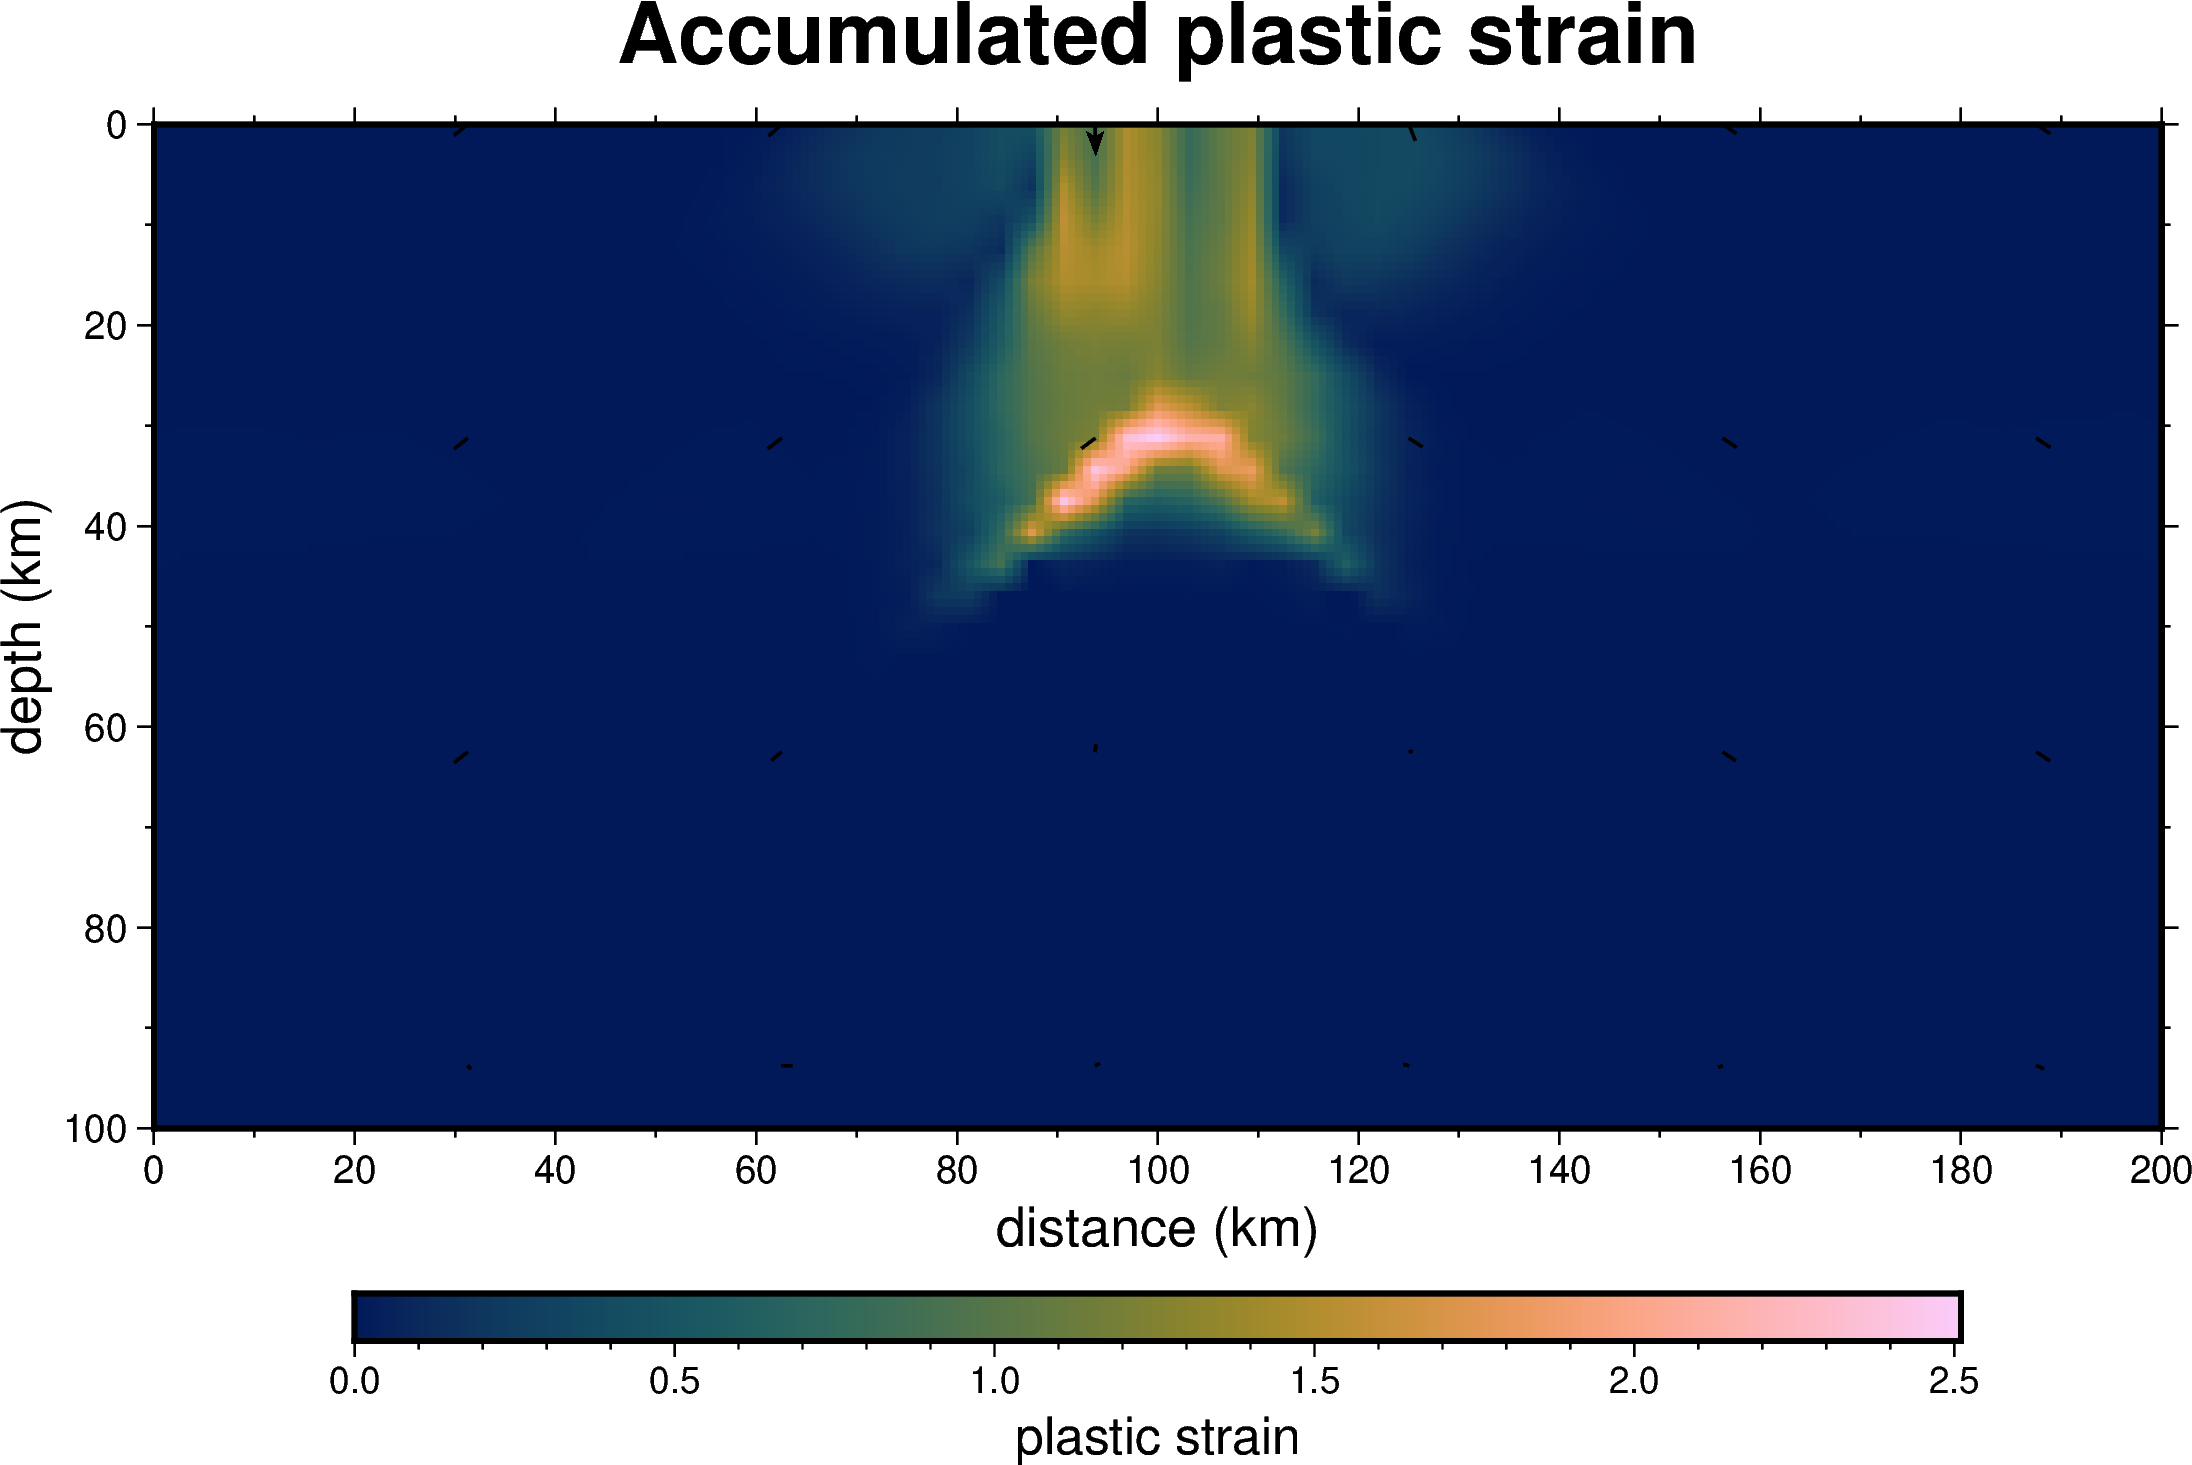

In [6]:
d = np.load("rift.npz")
fig = plotting.field_panel(
    d["strain"], d["x_km"], d["depth_km"], kind="strain_rate",
    title="Accumulated plastic strain", label="plastic strain",
    vx=d["vx"], vz=d["vz"], every=40, width_cm=17.0,
)
fig.show()

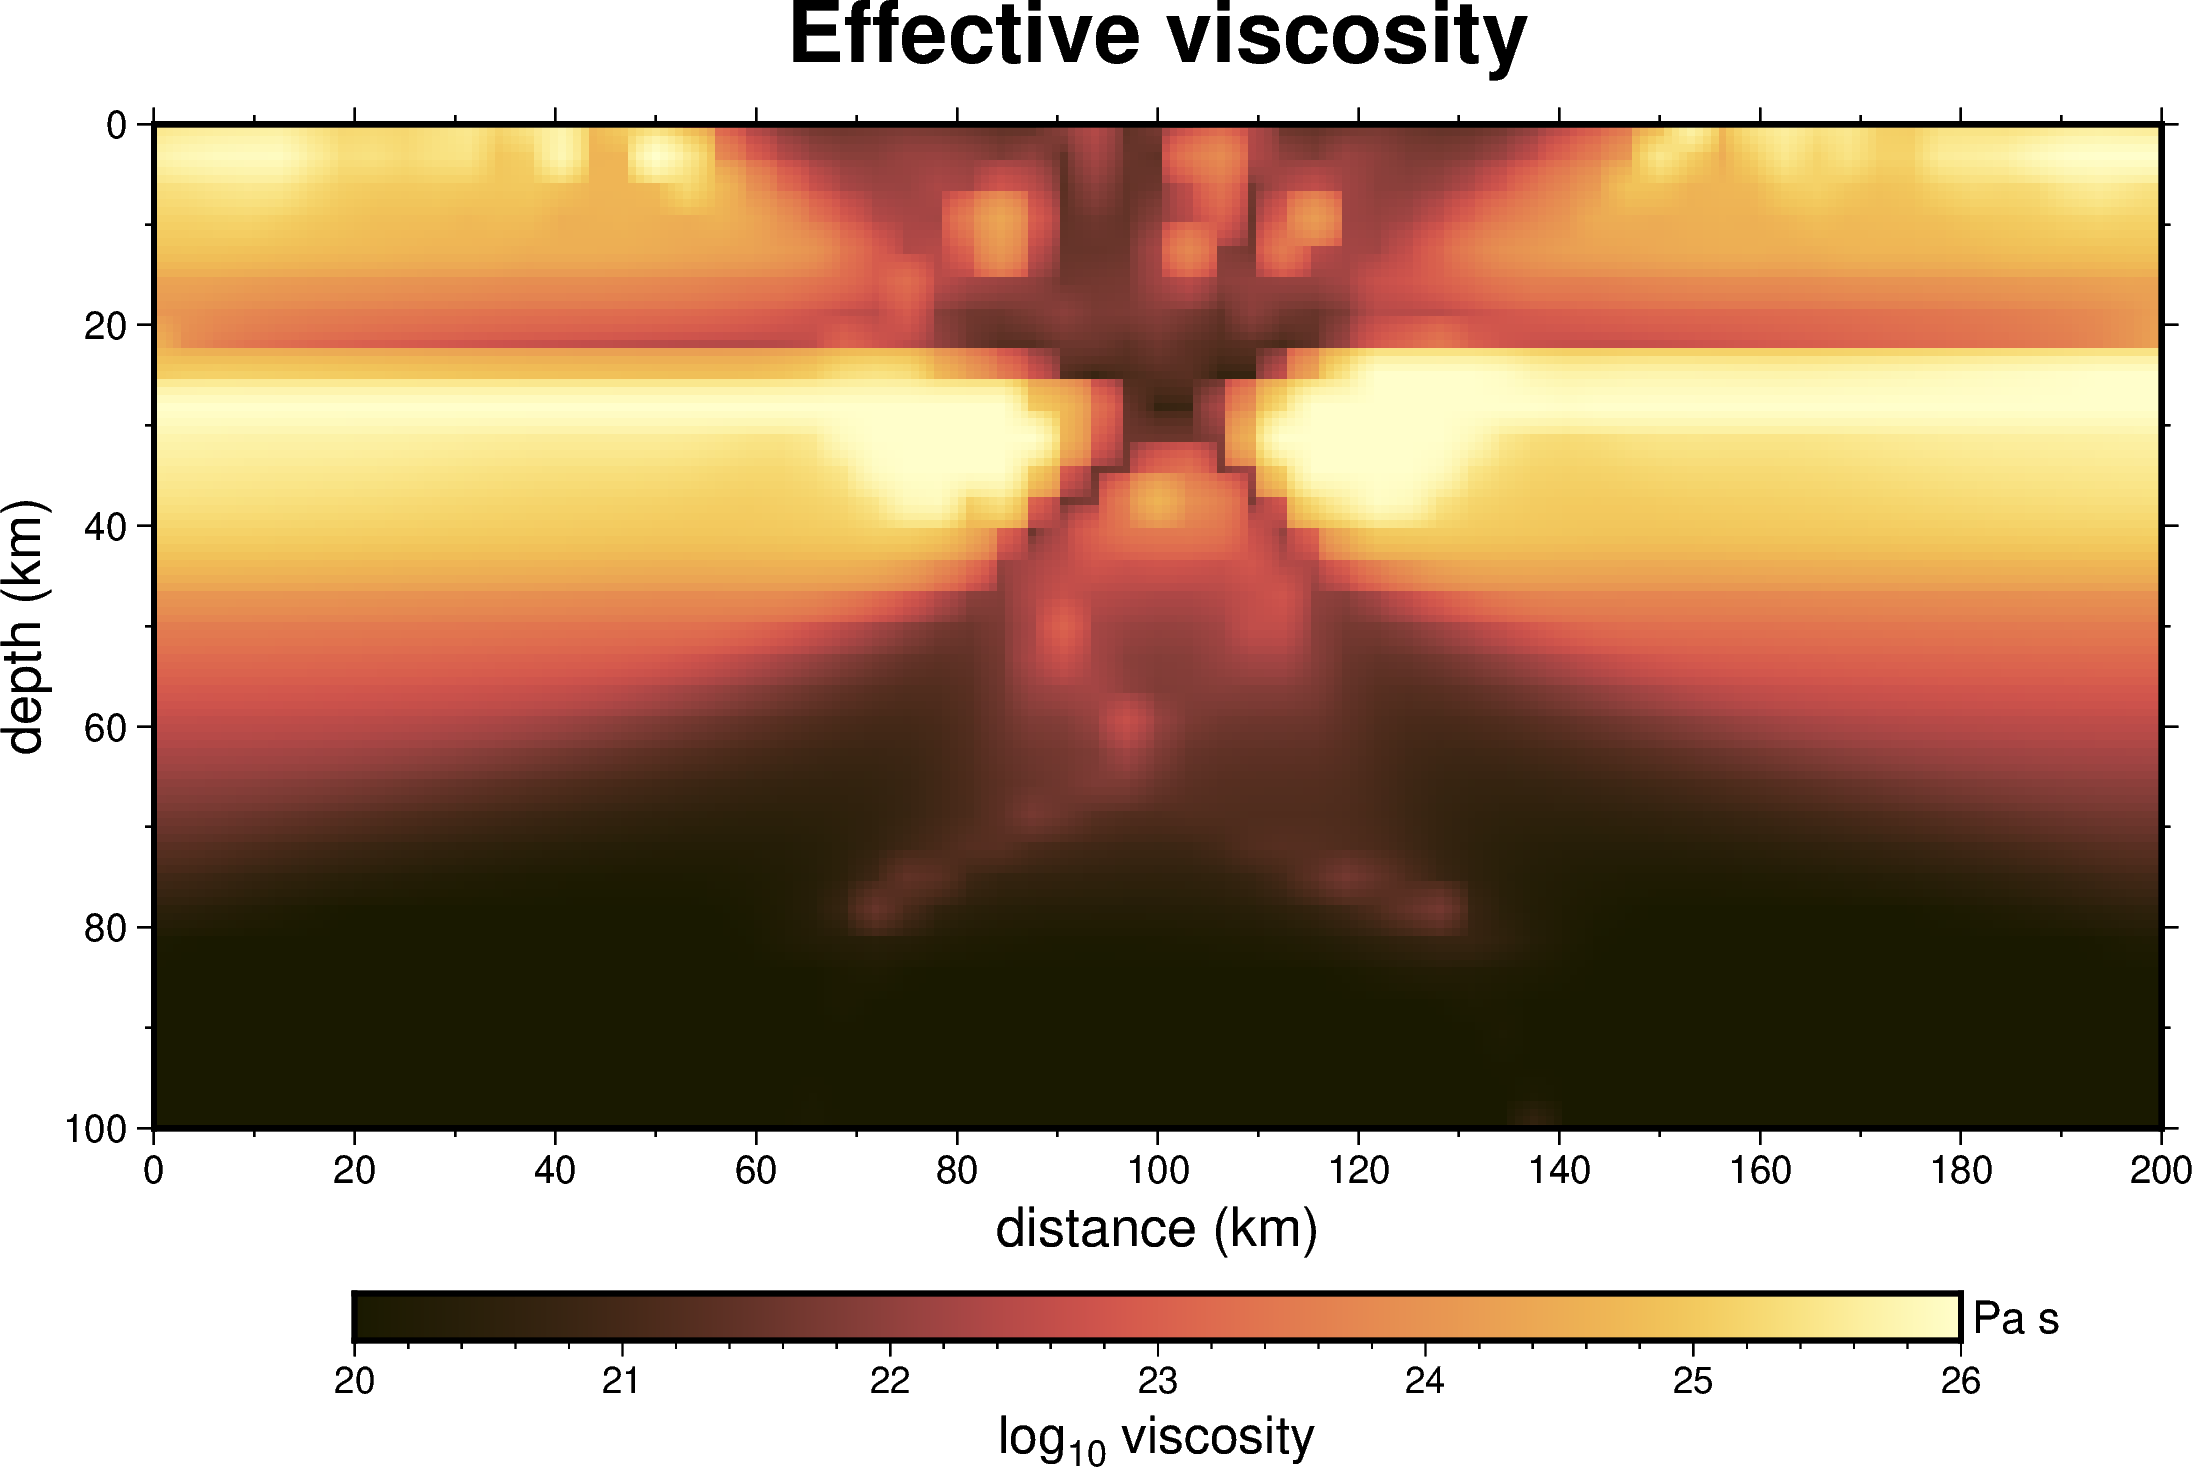

In [7]:
fig = plotting.field_panel(
    np.log10(np.maximum(d["viscosity"], 1e18)), d["x_km"], d["depth_km"],
    kind="viscosity", title="Effective viscosity",
    label="log@-10@- viscosity", unit="Pa s", width_cm=17.0,
)
fig.show()

A symmetric pair of conjugate shear zones dips inward from the base of the crust
and converges beneath the axis, with steeper faults carrying the deformation up
through the brittle upper crust. At 96×48 the upper-crustal part resolves into
three or four distinct strands rather than one — a fault *population*.

## 5. Is it actually localised?

Four questions, none of which is a ratio:

1. Is strain in the seed much larger than outside it?
2. Does peak strain grow **past the value the seed was given**? If not, you are looking at the seed, not at a fault.
3. Is the fully-weakened fraction small *and* non-zero? Small means localised; zero means nothing yielded.
4. Is mean strain low? A high mean means the whole domain failed.

In [8]:
print(f"1. in-seed / outside          {res['strain_in_seed']:.3f} vs "
      f"{res['strain_outside']:.3f}")
print(f"2. peak vs seeded maximum     {res['strain_max_final']:.3f} vs "
      f"{res['strain_max_initial']:.3f}  "
      f"{'GREW' if res['strain_max_final'] > res['strain_max_initial'] else 'did not grow'}")
print(f"3. fully weakened fraction    {res['weak_fraction_final']:.4%}")
print(f"4. mean strain                {res['strain_mean_final']:.4f}")

1. in-seed / outside          1.290 vs 0.092
2. peak vs seeded maximum     2.634 vs 1.485  GREW
3. fully weakened fraction    0.8230%
4. mean strain                0.0872


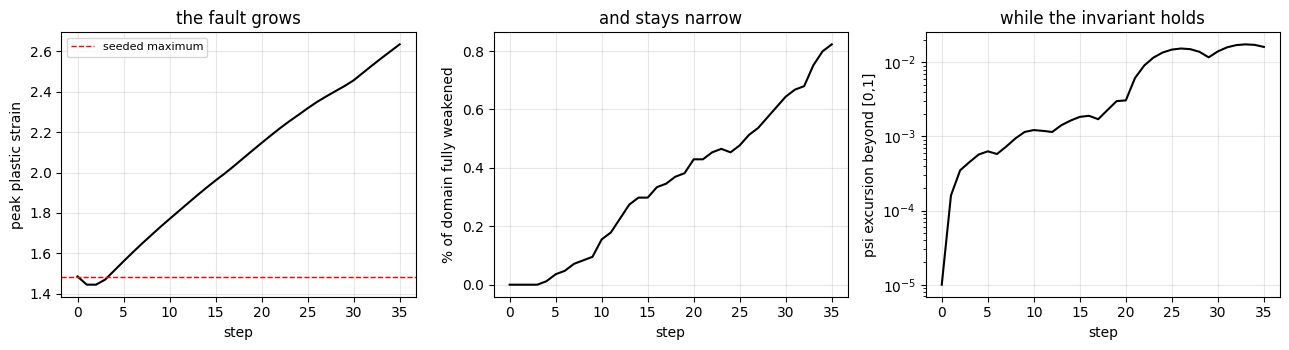

In [9]:
s = np.array([h["strain_max"] for h in hist])
w = np.array([h["weak_fraction"] for h in hist])
e = np.array([h["ls_excursion"] for h in hist])
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ax[0].plot(s, "k-")
ax[0].axhline(res["strain_max_initial"], color="r", ls="--", lw=1,
              label="seeded maximum")
ax[0].set(xlabel="step", ylabel="peak plastic strain", title="the fault grows")
ax[0].legend(fontsize=8)
ax[1].plot(100 * w, "k-")
ax[1].set(xlabel="step", ylabel="% of domain fully weakened",
          title="and stays narrow")
ax[2].semilogy(np.maximum(e, 1e-6), "k-")
ax[2].set(xlabel="step", ylabel="psi excursion beyond [0,1]",
          title="while the invariant holds")
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 6. How long is this model entitled to run?

Not as long as you would like, and neither limit is numerical stubbornness. Both
are consequences of what was left out, and they are worth deriving rather than
discovering.

### The lid imports rock

The mesh is Eulerian and fixed. Both walls are driven outward, the base is
no-flux, so by incompressibility whatever leaves through the sides must enter
through the top. Do not take that on trust — measure it:

In [10]:
top = 0
side = abs(d["vx"][:, 0]).mean() * 100.0 + abs(d["vx"][:, -1]).mean() * 100.0
inflow = abs(d["vz"][top]).mean() * 200.0
print(f"vz on the top boundary: mean {d['vz'][top].mean():+.4f} "
      "(non-dimensional; +ve is downward, boundary velocity is 1)")
print(f"outflow through the sides {side:.1f}   inflow through the top {inflow:.1f}")
print(f"mass balance closes to {100 * abs(side - inflow) / side:.2f}%")

H_KM, U0_CM_YR = 100.0, 0.25
T_MYR = H_KM * 1e5 / U0_CM_YR / 1e6          # H / U0 in Myr
dt_nd = 2e-3
step_myr = dt_nd * T_MYR
descent_m = (U0_CM_YR / 100.0) * (step_myr * 1e6)      # m/yr times yr
print(f"\ntime scale H/U0            {T_MYR:.1f} Myr")
print(f"one step at dt = {dt_nd:.0e}     {step_myr:.3f} Myr")
print(f"descent through the top     {descent_m:.0f} m per step")
print(f"after {STEPS} steps               {STEPS * descent_m / 1e3:.1f} km imported "
      f"({STEPS * descent_m / 20e3:.0%} of the upper crust)")
print(f"steps to replace the 20 km upper crust  {20e3 / descent_m:.0f}")

vz on the top boundary: mean +0.9990 (non-dimensional; +ve is downward, boundary velocity is 1)
outflow through the sides 200.0   inflow through the top 199.8
mass balance closes to 0.10%

time scale H/U0            40.0 Myr
one step at dt = 2e-03     0.080 Myr
descent through the top     200 m per step
after 36 steps               7.2 km imported (36% of the upper crust)
steps to replace the 20 km upper crust  100


The top boundary imports rock at the full boundary velocity, uniformly, from
nowhere. A real rift *subsides*; this one is held flat by a lid. After 36 steps
roughly 7 km has come in — a third of the upper crust — and you can see it in the
output: on the flanks the 20 km and 40 km interfaces now sit at about 26 and
46 km, pushed down bodily.

### The neck reaches the mesh

The second limit is sharper. At 96×48 the same model aborts at step 40 with the
excursion jumping from +0.0005 per step to +0.009 per step between steps 36 and
37 — eighteen-fold, with Courant number, iteration count and peak strain all
moving smoothly through it. The geometry at that moment says why:

| x (km) | upper crust | lower crust |
|---|---|---|
| 10 | 26.0 km | 20.3 km |
| 70 | 25.5 km | 19.8 km |
| **101.6 (axis)** | 30.2 km | **7.3 km** |
| 130 | 26.0 km | 19.3 km |

The lower crust has necked from 20 km to **7.3 km, which is 3.5 vertical cells.**
A conservative level set carries its $\tanh$ profile over roughly one cell either
side of the interface, so at 3.5 cells the two interfaces bounding that layer are
touching, and the reinitialisation of each corrupts the other. **You cannot
resolve a layer thinner than a few interface thicknesses**, and no amount of
tuning changes that.

Refining uniformly postpones rather than solves: 128×64 halves the cell, so the
layer could neck to about 5.5 km instead of 7.3 before hitting the same wall, at
2.3× the cost per step.

Notice that the two limits — the imported lid and the necking — arrive at almost
the same run length from completely different directions. That is a reasonably
strong hint that forty steps is simply what this configuration supports, and that
the way forward is different physics rather than more of the same.

## 7. Three metrics that lied

This is the part to take away, because it generalises well beyond rifting.

Every diagnostic below was defeated by the same mechanism: **it was maximised by
the failure mode it was supposed to detect.**

**The localisation ratio** — in-seed strain divided by outside strain — was used
to choose parameters for several rounds. It is maximised by a run in which
nothing deforms outside the seed, which includes every run in which nothing
deforms at all. One configuration scored 15.9 while producing no deformation
whatsoever. It has been removed from the output entirely.

**Total accumulated strain**, used to choose the geotherm, picked $q_0 = 0.040$
— the value at which the mantle lithosphere is too rigid to deform, so all the
strain is forced into the crust. Section 2.

**A layering check on fixed depth windows.** Comparing mean density in
22–38 km against 2900 kg/m³ is exactly right at $t = 0$, for catching a
mis-ordered material list, and wrong by construction as a runtime check: *a model
that extends moves its layers out of the windows*. It failed at step 39 with
lower crust 2858 kg/m³ both at the old reinitialisation setting and at one that
cut the level-set drift tenfold — the same step, the same digit. That
coincidence is what exposed it.

The invariant that survived is the one that is true regardless of how much the
model deforms: $\psi \in [0, 1]$. When you design a check, ask what it does on a
*successful* run, not just on a broken one.

A fourth, for completeness, because it is the same error in the solver: the
Picard iteration used to restore whichever iterate had the smallest update norm.
That is the iterate immediately after the isoviscous warm-up, whose update is
small because the starting field was smooth — and which, measured by
$\|\nabla\cdot\mathbf{u}\| / \|\nabla\mathbf{u}\|$, is the *least* incompressible
field in the whole iteration (0.52, against 0.11 for simply keeping the last
one). Fixing that, and rolling back after a failed Newton step, is most of why
this model localises at all.

## Extend this

* Set `--heatflow 0.070` and look at the strength envelope first. Where does the brittle–ductile transition move, and does the rift get wider?
* Halve `--seed-km`. Does the fault population change, or only its position?
* Run with `--reini-steps 6` and find the step at which the invariant fires. Does it scale the way the table in section 3 suggests?
* Turn off strain weakening (set the final weakening factor to 1.0 in `geodynkit.lithosphere`) and re-run. How much of the localisation was the seed, and how much was the feedback?
* Compute the brittle–ductile transition depths from `strength_envelope` for several geotherms and predict, before running, which will give a narrow rift and which a wide one.

**Next:** T11 takes the two limits found in section 6 seriously — adaptive mesh
refinement so the neck stays resolved, and a free surface so the model can
subside instead of importing rock through a lid.